---
title: US Market Trends Analysis
# subtitle: A Comprehensive Guide to Analyzing the S&P 500 Index Using Python
author: Samantha Pang
date: 2025-12-01
date-modified: last-modified 
format: 
    html: 
        toc: true
        code-fold: true
---


## Prerequisites!
Libraries needed for this exercise: yfinance, matplotlib, numpy, seaborn

## Objective
This project is to understand the leading indicators of the US stock market by analyzing the S&P500,  Dow Jones, and NASDAQ indices. We will explore historical data, visualize trends, and identify patterns that can help be well informed investors.

## leading indicators
### S&P 500 
The S&P 500, Standard & Poor's 500, is a stock market index that measures the stock performance of 500 large companies listed on stock exchanges in the US. It is one of the most commonly followed equity indices and is often considered a benchmark for the overall health of the US stock market.

### Dow Jones
The Dow Jones Industrial Average (DJIA) is a stock market index that measures the stock performance of 30 large, publicly-owned companies based in the US. It is one of the oldest and most widely recognized stock market indices in the world. 

### NASDAQ
The NASDAQ Composite is a stock market index that includes almost all stocks listed on the NASDAQ stock exchange. It is heavily weighted towards technology companies and is often used as a benchmark for the performance of the tech sector.

In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

startdate = "1990-01-01"
enddate = "2025-12-31"
tickers = ["^GSPC", "^DJI", "^IXIC"]

# auto_adjust=True to get adjusted close prices (accounting for dividends and stock splits)
df = yf.download(
    tickers,
    start=startdate,
    end=enddate,
    auto_adjust=True
)["Close"]

sp500, dw30, nasdaq = df["^GSPC"], df["^DJI"], df["^IXIC"]

# today/yesterday price ratio / gross return
def returns(prices):
    return np.log(prices/prices.shift(1)).dropna()

sp500ret, dw30ret, nasdaqret = returns(sp500), returns(dw30), returns(nasdaq)

[*********************100%***********************]  3 of 3 completed


Visialing the close price using histogram, we are seeing a non-normal distribution with a right skew, indicating that there are more days with lower closing prices and fewer days with very high closing prices. One of the reasons for the sparsed distribution as the close price is continuously increasing over the years, with a wide range of data point. 

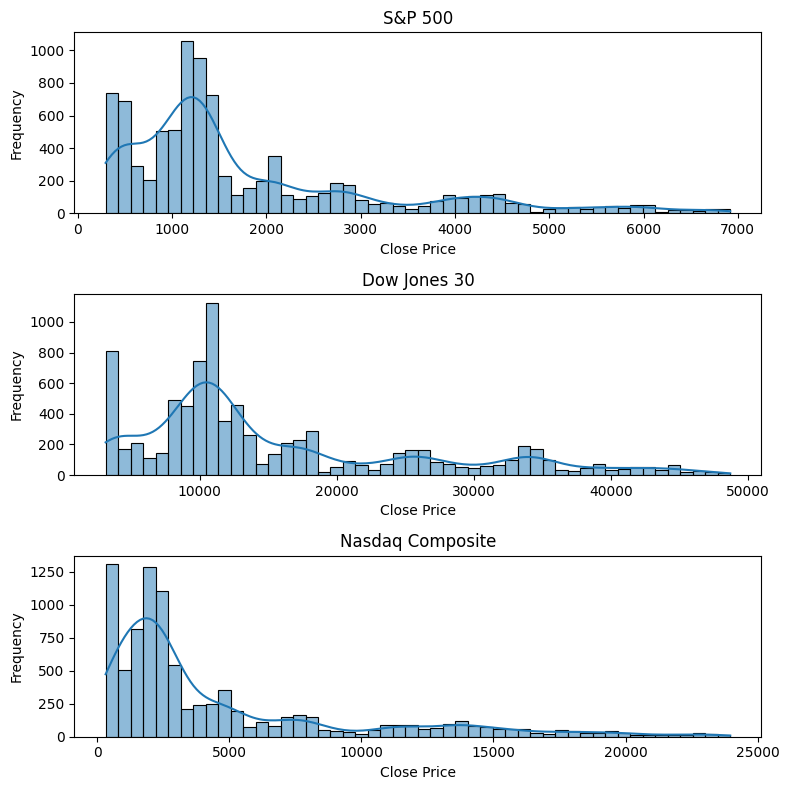

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8))
series_list = [sp500, dw30, nasdaq]

for series, name, i in zip(series_list, ["S&P 500", "Dow Jones 30", "Nasdaq Composite"], range(3)):
    sns.histplot(series, kde=True, bins=50, ax=axes[i])
    axes[i].set_title(name)
    for ax in axes:
        ax.set_xlabel("Close Price")
        ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

With log transformation, we can see a more normalized distribution. Log returns turn multiplicative processes into additive processes, making them easier to analyze statistically. 

Histogram shows more symmetric distributions of the logarithm return of all 3 of the indices over the last 30 year, which provides an insight into their performance and volatility. Majority of returns cluster around the mean indicates smaller data movement. The probability of extreme returns (both positive and negative) is low, suggesting limited risk of significant losses or gains within this period. Overall, the histogram suggests that all 3 indices has relatively stable performance with moderate volatility over the year, making them suitable for long-term investment strategies.

S&P 500 's Total Return Over Past 30 Years:  18.2372
S&P 500 's Annual Volatility:  0.1808
Dow Jones 30 's Total Return Over Past 30 Years:  14.3246
Dow Jones 30 's Annual Volatility:  0.1743
Nasdaq Composite 's Total Return Over Past 30 Years:  50.2692
Nasdaq Composite 's Annual Volatility:  0.2313


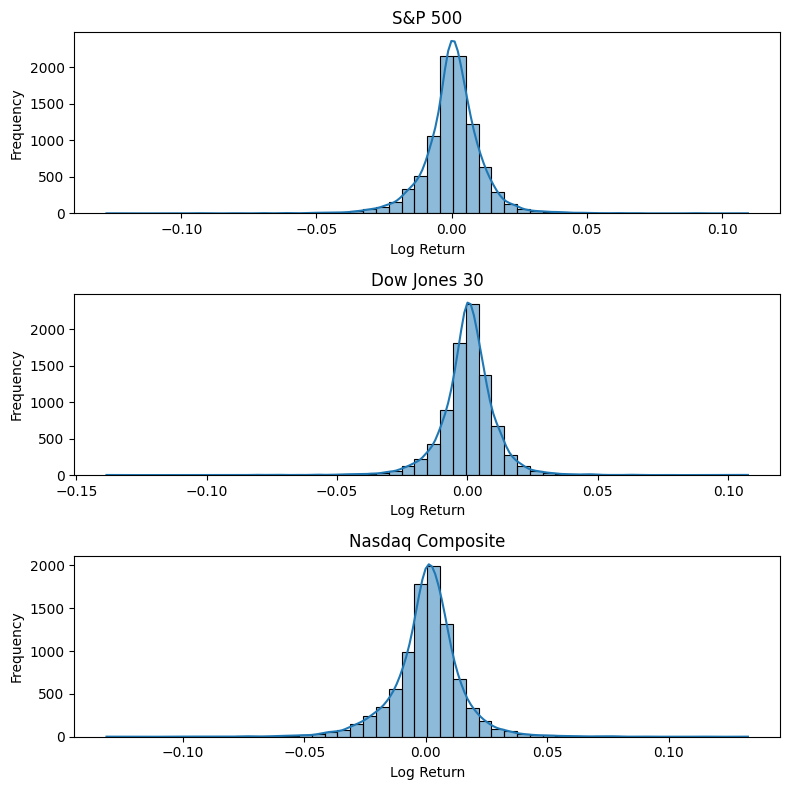

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8))
series_list = [sp500ret, dw30ret, nasdaqret]

for series, name, i in zip(series_list, ["S&P 500", "Dow Jones 30", "Nasdaq Composite"], range(3)):
    sns.histplot(series, kde=True, bins=50, ax=axes[i])
    axes[i].set_title(name)
    for ax in axes:
        ax.set_xlabel("Log Return")
        ax.set_ylabel("Frequency")
    print(name, "'s Total Return Over Past 30 Years: ",(np.exp(series.sum())-1).round(4))
    print(name, "'s Annual Volatility: ", (series.std()*np.sqrt(252)).round(4)) 

plt.tight_layout()
plt.show()

The total returns of 3 incides show significant return. NASDAQ has the highest return and volatility, 50.27/ 23%, i.e. $1 invested in NASDAQ would have grown to $50.27 over the last 30 years, and 23% of its value would fluctuate annually. On the other hand, Dow Jones has the lowest returns and volatility, and S&P 500 showing a more stable performance compared to NASDAQ.

The distribution of the log return of all 3 indices has a symmetric distribution, but we can also use statistical measures to confirm if it is a normal distribution. Let's find mean, median, skewness, kurtosis of log return for all 3 indices. zscore to identify outliers in log return.

In [5]:
for series, name in zip(series_list, ["S&P 500", "Dow Jones 30", "Nasdaq Composite"]):
    print(name, "'s mean, median, mode: ",series.mean().round(4), "/",series.median().round(4),"/", series.mode().round(4))
    print(name, "'s skewness, kurtosis: ", series.skew().round(4),"/", series.kurt().round(4)) 

S&P 500 's mean, median, mode:  0.0003 / 0.0006 / 0    0.0
Name: ^GSPC, dtype: float64
S&P 500 's skewness, kurtosis:  -0.3652 / 10.8804
Dow Jones 30 's mean, median, mode:  0.0003 / 0.0006 / 0    0.0
Name: ^DJI, dtype: float64
Dow Jones 30 's skewness, kurtosis:  -0.3852 / 13.0129
Nasdaq Composite 's mean, median, mode:  0.0004 / 0.0011 / 0    0.0
Name: ^IXIC, dtype: float64
Nasdaq Composite 's skewness, kurtosis:  -0.1798 / 6.8745


The means, medians, and mode of the indices are extremely close to each other, indicating that the distribution is indeed symmetric and centered around the same value. Skewness explains if distribution is left or right leaning, minimal left leaning is showing. The kurtosis measures the "tailedness" of the distribution. The kurtosis values are high for all, indicates extreme moves happen frequently. 

## Conclusion
All 3 indices show relatively stable performance with moderate volatility over the years. The S&P 500 and Dow Jones indices have a more stable performance compared to NASDAQ. NASDAQ has the highest return and volatility, making it suitable for investors who can tolerate high risk for potential high rewards. The distribution of log returns for all 3 indices is symmetric, but the kurtosis values are high, indicating frequent extreme moves. A friendly advice for investorsis to consider long-term investment strategies and to be prepared for potential market volatility. High returns came from surviving drawdowns and not timing the market.